##Name-Nancy
##Subject-Computer vision Lab
##CUID-CU240251005

#Experiment No. 6
Experiment Name :-
Implementation and Comparative Analysis of Image Segmentation Techniques using Python
and OpenCV

Steps
1. Import the required Python libraries and load a real-world image such as a medical
image, satellite image, or natural scene.


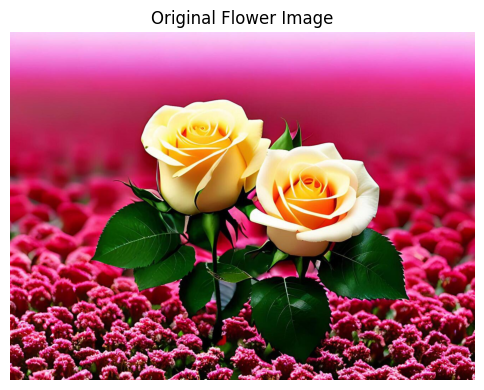

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
image = cv2.imread("/rose-flower-beautiful-flowers.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 5))
plt.imshow(image_rgb)
plt.title("Original Flower Image")
plt.axis("off")
plt.show()


2. Convert the image into grayscale and perform basic preprocessing to reduce noise using
Gaussian Blur.


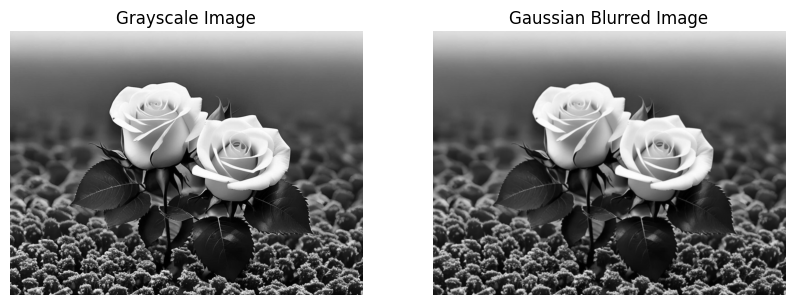

In [ ]:
# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.show()

3. Apply Global Thresholding to separate foreground objects from the background and
observe the segmentation results.



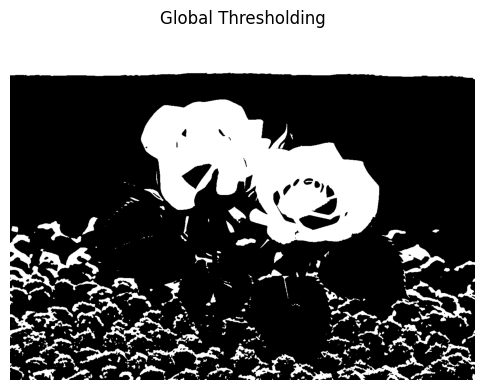

In [ ]:
threshold_value = 127
_, global_thresh = cv2.threshold(
    blur, threshold_value, 255, cv2.THRESH_BINARY
)
plt.figure(figsize=(6, 5))
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")
plt.show()

4. Implement Otsu's Thresholding to automatically determine the optimal threshold value
and compare it with global thresholding.



Otsu Optimal Threshold Value: 124.0


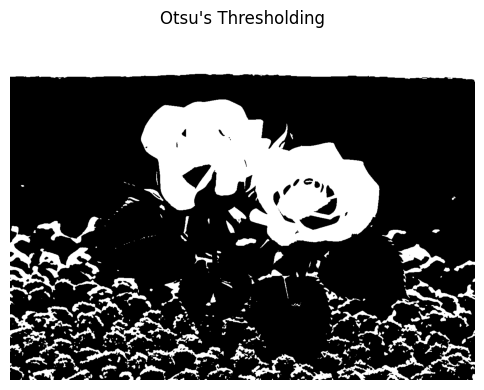

In [ ]:
otsu_value, otsu_thresh = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
print("Otsu Optimal Threshold Value:", otsu_value)
plt.figure(figsize=(6, 5))
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")
plt.show()

5. Apply Adaptive Thresholding to segment images with uneven illumination conditions.


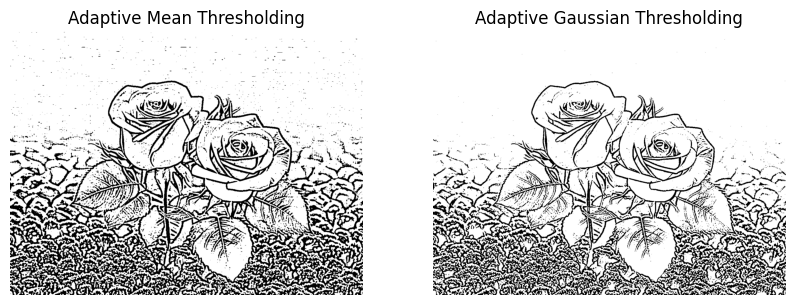

In [ ]:
# Adaptive Mean Thresholding
adaptive_mean = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11, 2
)

adaptive_gaussian = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11, 2
)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(adaptive_mean, cmap="gray")
plt.title("Adaptive Mean Thresholding")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(adaptive_gaussian, cmap="gray")
plt.title("Adaptive Gaussian Thresholding")
plt.axis("off")

plt.show()

6. Implement the Watershed Segmentation algorithm to separate overlapping or touching
objects within the image.



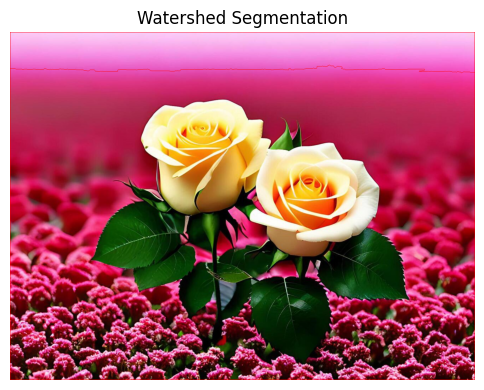

In [ ]:
binary = otsu_thresh.copy()
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(
    binary, cv2.MORPH_OPEN, kernel, iterations=2
)
sure_bg = cv2.dilate(opening, kernel, iterations=3)
dist_transform = cv2.distanceTransform(
    opening, cv2.DIST_L2, 5
)

_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255, 0
)

sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
markers = cv2.watershed(image, markers)
watershed_result = image_rgb.copy()
watershed_result[markers == -1] = [255, 0, 0]

plt.figure(figsize=(6, 5))
plt.imshow(watershed_result)
plt.title("Watershed Segmentation")
plt.axis("off")
plt.show()

7. Apply K-Means Clustering for color-based image segmentation by grouping pixels into
distinct clusters.



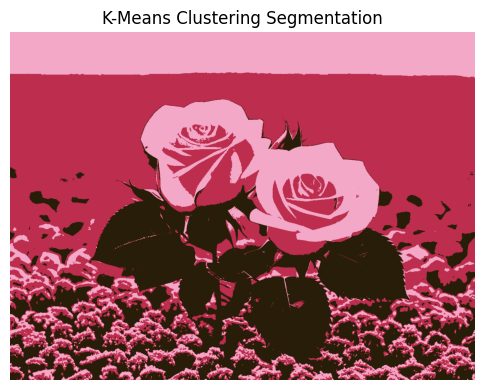

In [ ]:
# Convert image to RGB
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
pixels = rgb_image.reshape((-1, 3))
pixels = np.float32(pixels)
K = 3
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels)
centers = np.uint8(kmeans.cluster_centers_)

segmented_pixels = centers[labels]
segmented_image = segmented_pixels.reshape(rgb_image.shape)

plt.figure(figsize=(6, 5))
plt.imshow(segmented_image)
plt.title("K-Means Clustering Segmentation")
plt.axis("off")
plt.show()

8. Compare the segmentation outputs obtained from different techniques based on object
boundaries, accuracy, and computational efficiency.
9. Visualize and analyze the segmented images to identify the most suitable technique for
the selected dataset.


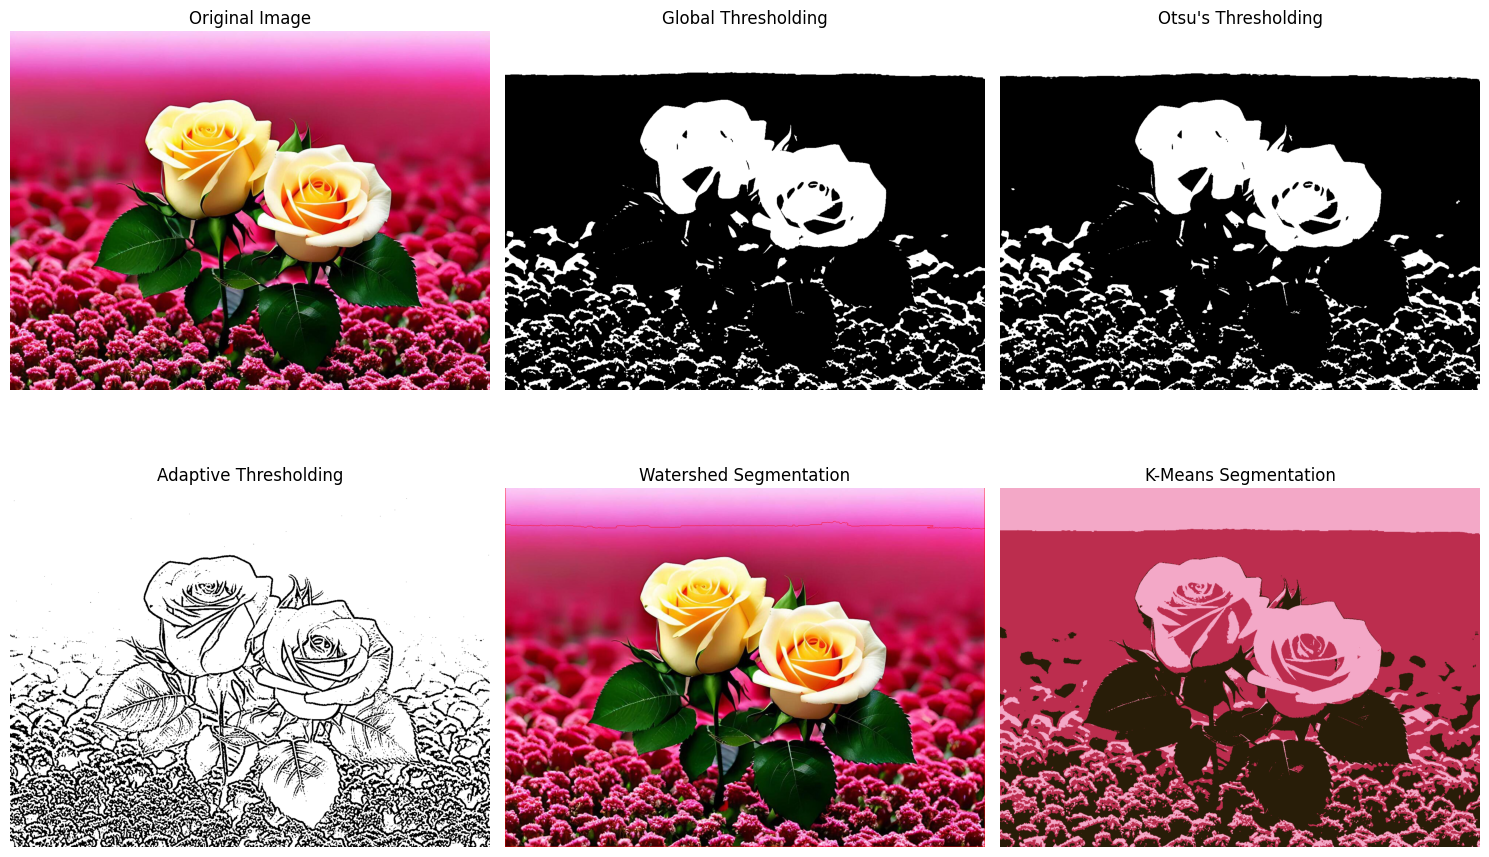

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_thresh, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_thresh, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_gaussian, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(watershed_result)
plt.title("Watershed Segmentation")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(segmented_image)
plt.title("K-Means Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

10. Summarize the observations and discuss the role of image segmentation in advanced
computer vision applications.

In [ ]:
print("OBSERVATIONS AND CONCLUSION")
print("1. Global Thresholding provides simple and fast segmentation.")
print("2. Otsu's Thresholding automatically selects the optimal threshold.")
print("3. Adaptive Thresholding works well with uneven illumination.")
print("4. Watershed Segmentation is useful for separating touching objects.")
print("5. K-Means Clustering is effective for color-based segmentation.")
print("\nFor the selected flower image, K-Means Clustering")
print("is suitable because it separates regions based on color.")
print("\nROLE OF IMAGE SEGMENTATION")
print("Image segmentation divides an image into meaningful regions.")
print("It helps in object detection, image recognition, medical imaging,")
print("autonomous vehicles, satellite imaging, agriculture, and robotics.")
print("It improves the identification of object boundaries, shape, size,")
print("and location, making computer vision systems more accurate.")

OBSERVATIONS AND CONCLUSION
1. Global Thresholding provides simple and fast segmentation.
2. Otsu's Thresholding automatically selects the optimal threshold.
3. Adaptive Thresholding works well with uneven illumination.
4. Watershed Segmentation is useful for separating touching objects.
5. K-Means Clustering is effective for color-based segmentation.

For the selected flower image, K-Means Clustering
is suitable because it separates regions based on color.

ROLE OF IMAGE SEGMENTATION
Image segmentation divides an image into meaningful regions.
It helps in object detection, image recognition, medical imaging,
autonomous vehicles, satellite imaging, agriculture, and robotics.
It improves the identification of object boundaries, shape, size,
and location, making computer vision systems more accurate.
